In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gs
import pandas as pd
from datetime import datetime as DT
from datetime import timedelta
import calendar
import seaborn as sns
from scipy.optimize import curve_fit as cf
from collections import deque

# Copying over functions from Task One
(and slightly editing some)

### much of the hard part is already done

In [2]:
def X_date_format(fig,ax,locate='D',major_int=15,minor_int=5, minor_label=False):
    if locate=='D':
        locator = mdates.DayLocator
    if locate=='M':
        locator = mdates.MonthLocator
    
    ax.xaxis.set_major_locator(locator(interval=major_int))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_minor_locator(locator(interval=minor_int))
    if minor_label:
        ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

    fig.autofmt_xdate()


def Mean(t,A,B,C,D,E):
    return A*t + B*np.sin(C*t + D) + E


def date_list(start_date, end_date, last_day_of_month=False):
    """
    Input a start and end date and output all dates in between, inclusive.
    Accepts strings, datetime objects, or pandas Timestamps.
    
    If last_day_of_month=True, it will return only the last day of each month
    between the dates.
    """
    # Convert inputs to Timestamps (works with str, datetime, np.datetime64)
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    start_date, end_date = sorted([start_date, end_date])
    
    if last_day_of_month:
        # monthly frequency
        dates = pd.date_range(start=start_date, end=end_date, freq="M")
    else:
        # daily frequency
        dates = pd.date_range(start=start_date, end=end_date, freq="D")
    return pd.Series(dates)

### WE ONLY NEED SIMULATE THE FUTURE ###

def Simulate_Future(dates_list, n_paths=100,DOWNTUNE_SLOPE=1.0):
    """ 
    Function that takes in a list of dates in the future (relative to the original data) and
    returns n_paths simulations which can be used to estimate statistics.
    dates_list should be a pandas Series.
    DOWNTUNE_SLOPE must be > 0 and <= 1
    """
    if DOWNTUNE_SLOPE > 1 or DOWNTUNE_SLOPE < 0:
        print("DOWNTUNE_SLOPE must be between 0 and 1.")
        return
    delta_days = (dates_list.sort_values() - data.index[-1]).dt.days
    
    First_Day = delta_days.iat[0]
    if First_Day < 0:
        print("Only future dates allowed.")
        return
#     n_paths = 100

    DAY_SHIFT = (data.index[-1] - data.index[0]).days
    Last_Day = delta_days.iat[-1]
    n_steps = Last_Day
    
    # Since we will now simulate DAILY values, we need to transfrom our rates (parameters)
    # Before we had delta_t ~ 1 month, so now we need to scale from months to days
    # Let's assume there are 365/12 = 30.4 days in a month and convert to the proper date afterwards
    dt = 1/30.4
    X = np.arange(DAY_SHIFT,Last_Day+1+DAY_SHIFT,1,dtype=float)
    a,b,c,d,e = MofT_params
    # rescaling paramteres, only a and c need to be rescaled
    a *= dt
    c *= dt
    
    MofT = Mean(X,a*DOWNTUNE_SLOPE,b,c,d,e)
    noise = np.random.normal(0,1,size = (n_paths,n_steps))
    dM = np.diff(MofT)
    sigma = np.sqrt(var)

    # calculate steps with scaled mean fit and variance
    increments = dM + sigma*np.sqrt(dt)*noise
    paths = np.zeros((n_paths,n_steps+1))
    paths[:,0] = data['Prices'][-1]
    
    #calculate path is cumulative sum of increments and initial condition
    paths[:,1:] = np.cumsum(increments, axis=1) + data['Prices'][-1]
    
    X = pd.Series(X)
    new_date_index = data.index[0] + pd.to_timedelta(X, unit='D')
    paths = pd.DataFrame(paths.transpose(), index=new_date_index)
    MofT = pd.Series(MofT, index=new_date_index)
    
    return paths,MofT



# Initial Data Processing

## Load Data

In [3]:
data = pd.read_csv('Nat_Gas.csv')
data['Dates'] = pd.to_datetime(data['Dates'], format="%m/%d/%y")
data.set_index("Dates",inplace=True)

## Fit Data

In [4]:
X = np.arange(data["Prices"].size)
MofT_FIT = cf(Mean,X,data["Prices"].values, p0=[0.5,3,0.5,0,10])
MofT_params = MofT_FIT[0]


MofT = Mean(X,*MofT_params)
MofT = pd.DataFrame(MofT,columns=['Prices'])
MofT.index = data.index

var = (1/data['Prices'].size) * np.sum( ( data['Prices'] - MofT['Prices'] )**2 )

# Pricing Function

We take "assume there is no transport delay" to mean that "Injection Date" = "Buy Date" and "Withdrawal Date" = "Sell Date" and that everything which can be withdrawn on the day is sold on the day. Additionally, we work with a model that is independent of the number of storage facilities, i.e. prices only scale with the volume.

### Function used for testing pricing function

In [5]:
def random_date_generator(start_date, range_in_days, size=1):
    days_to_add = np.arange(0, range_in_days)
    random_dates = np.datetime64(start_date) + np.random.choice(days_to_add,size=size,replace=False)
    return random_dates

### Conversion:

In [6]:
# Pricing usually given in MMBtu,
# but storage in volume are usually in Mcf or MMcf (1,000 cubic feet and 10^6 cubic feet respectively)
# "per Mcf divided by 1.038 equals $ per MMBtu" - https://www.eia.gov/tools/faqs/faq.php?id=45&t=8
# i.e. McF/MMBtu = 1.038

# both defined as multiplicative conversion factors
_perMcf_to_perMMbtu = 1/1.038 
_perMMBtu_to_perMcf = 1.038

### Pricing:

(max and min deliverability are not necessarily realistic numbers here)   
(a common heuristic for e.g. max delivarbility is $\sim 1-3\%$, not $30\%$)

In [7]:
def deliverability(volume, MAX_vol, min_deliv=0.1, max_deliv=0.3):
    """
        Model that assumes the delierabilty is linearly proportional to the occupied volume.
        volume and MAX_vol should be given in the same units.
        
        min_deliv and max_deliv determines the range
        
        return_volume flag decides whether the function returns the volume able to be withdrawn
        in a single day or the percentage
    """
    if not (volume > 0 and volume < MAX_vol):
        print("Volume out of proper range, return NaN.")
        return float('nan')
    frac = min_deliv + (max_deliv - min_deliv)*volume/MAX_vol
    return frac*volume
    
def injection_rate(volume, MAX_vol, min_deliv=0.1, max_deliv=0.3):
    """
        Model that assumes the injection rate is linearly proportional to the occupied volume.
        volume and MAX_vol should be given in the same units.
        
        min_deliv and max_deliv determines the range
        
        return_volume flag decides whether the function returns the volume able to be withdrawn
        in a single day or the percentage.
    """
    if not (volume >= 0 and volume < MAX_vol):
        print("Volume out of proper range, return NaN.")
        return float('nan')
    frac = max_deliv - (max_deliv - min_deliv)*volume/MAX_vol
    return frac*(MAX_vol - volume)


def Pricing(Injections_and_Withdrawls, inject_withdraw_price=0.02,  MAX_VOL=20_000, 
            storage_cost_rate=0.01):
    """
        Function which outputs relevent information in regards to buying and storing natural gas.
        Injections and Withdrawls are the required input and profit calculations are
        done assuming Injection Date/Withdrawl Date = Buy Date/Sell Date.
        
        Injections_and_Withdrawls should be a pandas Series indexed by the date with a signed 
        volume column that indicates Injection with a +1 and Withdrwal with a -1.
        
        Injections_and_Withdrawls: Dates|(+/-)Volume
        
        inject_withdraw_price is per day per Mcf
        
        Volume units should be given in Mcf (1000s of cubic feet).
        MAX_VOL should be thought of as the max voume accross "all" facilities, with each 
        Injection/Withdrawl being performed equally across all stoarge units.
        
        storage_cost_rate is per day per Mcf
    """
    InW = Injections_and_Withdrawls.sort_index()
    
    # Create date list for prive movements. We care about price movements
    # from the first _action_ to the last _action_, where action is withdrawl or injection
    start_date = InW.index[0]
    # Make sure that the first atcion is an injection
    if InW[start_date] < 0:
        print("Error, pricing simulation must start with injection.")
        return None
    end_date = InW.index[-1]
    dates_list = date_list(start_date, end_date)
    
    # create price movements and convert to Mcf
    price_movements, avg = Simulate_Future(dates_list,n_paths=1000)
    price_movements *= _perMMBtu_to_perMcf
    avg *= _perMMBtu_to_perMcf
        
    # There needs to be a base rate of volume stored
    base_volume = 1
    volume_stored = base_volume
    
    date_int_map = {date: value for date, value in zip(dates_list, range(dates_list.size))}
    # dates_lsit.size - 1, with - 1 because the last day in the dates_list
    # is dealt with differently in the for loop
    daily_profits = np.zeros(shape=(dates_list.size - 1,price_movements.shape[1]))
    nextInW = InW.index[1:]
    
    # The logic of the actual pricing engine gets complicated because we are limited by
    # injectection and withdrawl rates.
    # We will assume the gas is only bought/sold on the day it gets injected/withdrawn.
    # Unfortunately, this means that unless ample time is given between injection and
    # withdrawl dates, it could be that gas purchase/sell totals will be less than initially
    # requested.
    # In principle, I believe this makes more sense, since you don't want to inflate or
    # deflate the value of a contract based on gas that you couldn't store anywhere
    
    for i,(date,iw) in enumerate(zip(InW.index,InW)):
#### Begin outer loop

        if i < nextInW.size:
######## Begin outer "if"

            DaysBetweenActions = (nextInW[i] - date).days
#             profit = 0
            profit = np.zeros(shape=(price_movements.shape[1]))
            action_volume = iw
            
            # The volume of gas we work with between now and the next injection/withdrawl
            # is action_volume
            # Below is a loop over days beteen I/W actions
            for d in range(DaysBetweenActions):
############ Begin inner loop

                between_date = date+pd.DateOffset(d)
                profit -= volume_stored*storage_cost_rate      
        
                # a positive action_volume indicates buying
                # only buy if you have room to store more
                if action_volume>0 and volume_stored<MAX_VOL:
################ Begin inner "if"s
                    
                    injected = injection_rate(volume_stored,MAX_VOL)
                    # if you can inject more than you need to buy, complete the buying process
                    if action_volume - injected < 0:
                        injected = action_volume
                    # increase volume by injected amont
                    volume_stored += injected
                    # make sure to not fill past max storage
                    if volume_stored > MAX_VOL:
                        injected -= volume_stored - MAX_VOL
                        volume_stored = MAX_VOL
                    action_volume -= injected
#                     profit -= injected*avg[between_date]
                    profit -= injected*price_movements.loc[between_date]
                    profit -= injected*inject_withdraw_price
                    
                # a negative action volume indicates selling
                # only sell if your stored volume is greater than 0
                elif action_volume<0 and volume_stored>base_volume:
                    
                    withdrawn = deliverability(volume_stored,MAX_VOL)
                    # if you can withdraw more than you need to sell, complete the process
                    if action_volume + withdrawn > 0:
                        withdrawn = -action_volume #remember that action_volume is signed (-) for selling
                    volume_stored -= withdrawn
                    # make sure not to sell more than you have
                    if volume_stored < base_volume:
                        withdrawn -= base_volume - volume_stored
                        volume_stored = base_volume
                    action_volume += withdrawn
#                     profit += withdrawn*avg[between_date]
                    profit -= injected*price_movements.loc[between_date]
                    profit -= withdrawn*inject_withdraw_price
                    
################ End inner "if"s

                daily_profits[date_int_map[between_date]] = profit
    #             profit = 0
                profit = np.zeros(shape=(price_movements.shape[1]))

############ End inner loop

#             daily_profits = daily_profits.copy()

######## End outer "if"

        # data safety measure to ease fragmentation
        # Only hit on the last loop iteration 
        # Finally, on the last day, we sell all we have every day until we have no more
        else:
            # First, check to make sure the last action is to sell
            if iw > 0:
                print("You have no choice but to sell at the last!")
                iw *= -1
            profit = 0
            
            action_volume = iw
            d = 0
            last_profits = []
            dateInt = date_int_map[date]
            while volume_stored > base_volume:
############ Begin while loop
                profit -= volume_stored*storage_cost_rate
                
                after_date = date+pd.DateOffset(d)
                d += 1
                withdrawn = deliverability(volume_stored,MAX_VOL)
                volume_stored -= withdrawn
                # make sure not to sell more than you have
                if volume_stored < base_volume:
                    withdrawn -= base_volume - volume_stored
                    volume_stored = base_volume
                action_volume += withdrawn
                profit += withdrawn*price_movements.loc[between_date]
                
                last_profits.append(profit)
                date_int_map[after_date] = dateInt
                dateInt += 1
#                 daily_profits[after_date] = profit
#                 print(profit)
                profit = 0
############ End while loop
            daily_profits = np.concatenate((daily_profits,np.asarray(last_profits)),axis=0)
            daily_profits = pd.DataFrame(daily_profits,index=date_int_map.keys())
            
#### End outer loop
    
    return daily_profits
            

# Results

### For the first round of results, let's take one day in the summer and one day the following winter

In [8]:
d1 = np.datetime64('2025-06-21')
d2 = np.datetime64('2026-01-01')
dates = pd.to_datetime([d1,d2])
volumes = np.array([18,float('nan')])*1000 #last listed volume is meaningless since we sell all
InW = pd.Series(volumes,index=dates,)
daily_profits = Pricing(InW)
cumulative_profits = daily_profits.cumsum()
cumulative_profits.loc[cumulative_profits.index[0] + timedelta(days=-1)]  = 0
cumulative_profits.sort_index(inplace=True);

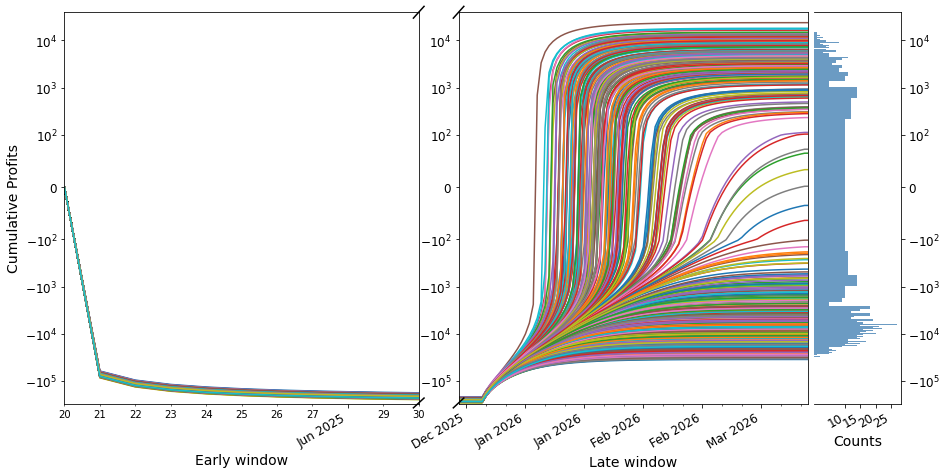

In [9]:
early = cumulative_profits.index <= '2025-06-30'
late  = cumulative_profits.index >='2025-12-25'

fig = plt.figure(figsize=(15, 8), constrained_layout=False)
grid = gs.GridSpec(1, 2, width_ratios=[2, 2.5], wspace=0.1)

ax1 = fig.add_subplot(grid[0])

grid_right = grid[1].subgridspec(1, 2, width_ratios=[4,1], wspace=0.025)
ax2      = fig.add_subplot(grid_right[0], sharey=ax1)  # late window
ax_hist  = fig.add_subplot(grid_right[1], sharey=ax1)


# Plot early window
ax1.plot(cumulative_profits.index[early], cumulative_profits[early])
ax1.set_xlim(cumulative_profits.index[early].min(), cumulative_profits.index[early].max())

# Plot late window
ax2.plot(cumulative_profits.index[late], cumulative_profits[late])
ax2.set_xlim(cumulative_profits.index[late].min(), cumulative_profits.index[late].max())

X_date_format(fig,ax1,major_int=9,minor_int=1,minor_label=True)
X_date_format(fig,ax2)

# for ax in (ax1, ax2):
#     ax.xaxis.set_major_locator(mdates.AutoDateLocator())
#     ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    

# Add diagonal break marks between axes
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d+0.005, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d+0.005, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Setting histogram
final_values = cumulative_profits.iloc[-1, :]
ax_hist.hist(final_values, bins=150, orientation="horizontal",
             color="steelblue", alpha=0.8)
ax_hist.set_xticks([10,15,20,25])
# ax_hist.set_xlabel("")
ax_hist.spines['left'].set_visible(False)
ax_hist.yaxis.tick_right()
ax_hist.yaxis.set_label_position("left")

# Tidy
ax1.set_xlabel('Early window',fontsize=14); ax2.set_xlabel('Late window',fontsize=14)
ax1.set_ylabel('Cumulative Profits',fontsize=14)
ax_hist.set_xlabel('Counts',fontsize=14)

ax1.set_yscale('symlog',linthresh=100)
ax2.set_yscale('symlog',linthresh=100)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.tick_params(axis='both', which='minor', labelsize=10)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='minor', labelsize=10)
ax_hist.tick_params(axis='both', which='major', labelsize=12)
ax_hist.tick_params(axis='both', which='minor', labelsize=10)

# plt.tight_layout()
plt.show()

## Contract Pricing:   
The distribution in the histogram on the right gives the distribution on profits at the end. In general, this is not trival to price, as the simulation was not necessarily done under a risk netural measure. In practice, one could take a measure-reweighting on the final distribution with an appropriate averaging to find the final contract price.

### Now let's try buying twice in the summer and selling twice in the winter

In [457]:
d1 = np.datetime64('2025-06-21')
d2 = np.datetime64('2025-07-15')
d3 = np.datetime64('2025-12-01')
d4 = np.datetime64('2026-01-01')

dates = pd.to_datetime([d1,d2,d3,d4])
volumes = np.array([9,9,-5,float('nan')])*1000 
InW = pd.Series(volumes,index=dates,)
daily_profits = Pricing(InW)
cumulative_profits = daily_profits.cumsum()
cumulative_profits.loc[cumulative_profits.index[0] + timedelta(days=-1)]  = 0
cumulative_profits.sort_index(inplace=True);

<Axes: >

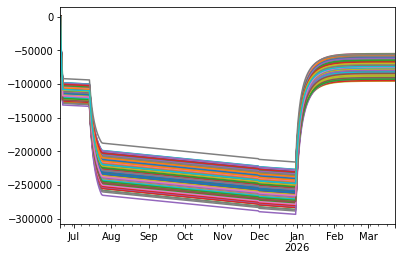

In [458]:
cumulative_profits.plot(legend=False)

### It's quite hard to make a profit that way..